In [1]:
# Check venv matches:
# C:\Users\mitch\source\repos\mtg_ai\.venv\Scripts\python.exe
import sys
print(sys.executable)

C:\Users\mitch\AppData\Local\Programs\Python\Python310\python.exe


In [2]:
# imports
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# Make pandas usable for wide MTG data
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 0)

In [3]:
# confirm path to data
PROJECT_ROOT = Path("../../..").resolve()
print(PROJECT_ROOT)
DATA_DIR = PROJECT_ROOT / "data" / "base"
MISC_PATH = DATA_DIR / "misc.parquet"
print(MISC_PATH)

# Load parquet to dataframe
cards_misc = pd.read_parquet(MISC_PATH)
# Basic shape and schema
print(cards_misc.shape)
cards_misc.head(5)

C:\Users\mitch\source\repos\mtg_ai
C:\Users\mitch\source\repos\mtg_ai\data\base\misc.parquet
(33561, 7)


,id,oracle_id,name,edhrec_rank,penny_rank,life_modifier,hand_modifier
0,0000419b-0bba-4488-8f7a-6194544ce91e,b34bb2dc-c1af-4d77-b0b3-a0fb342a5fc6,Forest,NaN,NaN,None,None
1,0000579f-7b35-4ed3-b44c-db2a538066fe,44623693-51d6-49ad-8cd7-140505caf02f,Fury Sliver,9980.0,11877.0,None,None
2,00006596-1166-4a79-8443-ca9f82e6db4e,8ae3562f-28b7-4462-96ed-be0cf7052ccc,Kor Outfitter,20283.0,5962.0,None,None
3,00009878-d086-46f0-a964-15734d8368ac,30cd69a8-7893-4075-94ca-04450ff821d3,Spirit of the Hearth,15522.0,14718.0,None,None
4,0000cd57-91fe-411f-b798-646e965eec37,9f0d82ae-38bf-45d8-8cda-982b6ead1d72,Siren Lookout,19805.0,13887.0,None,None


In [4]:
cards_misc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33561 entries, 0 to 33560
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             33561 non-null  object 
 1   oracle_id      33480 non-null  object 
 2   name           33561 non-null  object 
 3   edhrec_rank    31120 non-null  float64
 4   penny_rank     17755 non-null  float64
 5   life_modifier  0 non-null      object 
 6   hand_modifier  0 non-null      object 
dtypes: float64(2), object(5)
memory usage: 1.8+ MB


In [5]:
# Identity checks
print(f"Rows: {len(cards_misc):,}")
print(f"Unique id: {cards_misc['id'].nunique():,}")
print(f"Unique oracle_id: {cards_misc['oracle_id'].nunique():,}")

print(f"Duplicate id rows: {cards_misc['id'].duplicated().sum():,}")
print(f"Duplicate oracle_id rows: {cards_misc['oracle_id'].duplicated().sum():,}")

Rows: 33,561
Unique id: 33,561
Unique oracle_id: 33,480
Duplicate id rows: 0
Duplicate oracle_id rows: 80


In [6]:
# Missing values overview
missing = cards_misc.isnull().sum().sort_values(ascending=False)

missing[missing > 0]

life_modifier    33561
hand_modifier    33561
penny_rank       15806
edhrec_rank       2441
oracle_id           81
dtype: int64

Non-null EDHREC rows: 31,120


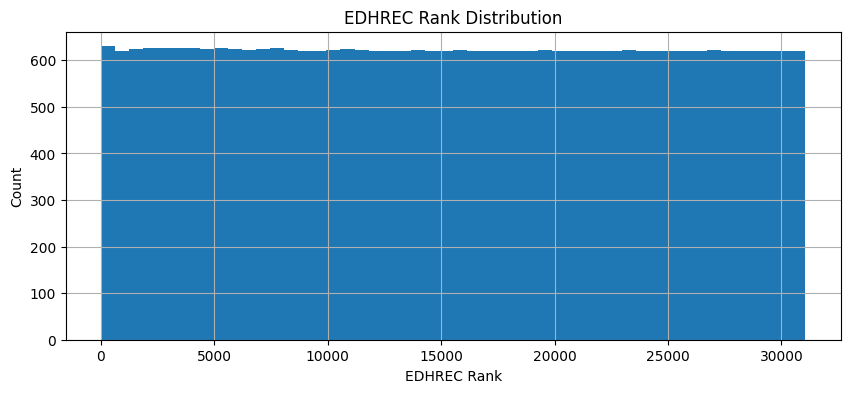

In [7]:
# EDHREC rank distribution
if "edhrec_rank" in cards_misc.columns:
    edhrec_non_null = cards_misc["edhrec_rank"].dropna()

    print(f"Non-null EDHREC rows: {len(edhrec_non_null):,}")

    edhrec_non_null.hist(bins=50, figsize=(10, 4))
    plt.title("EDHREC Rank Distribution")
    plt.xlabel("EDHREC Rank")
    plt.ylabel("Count")
    plt.show()

Non-null Penny Rank rows: 17,755


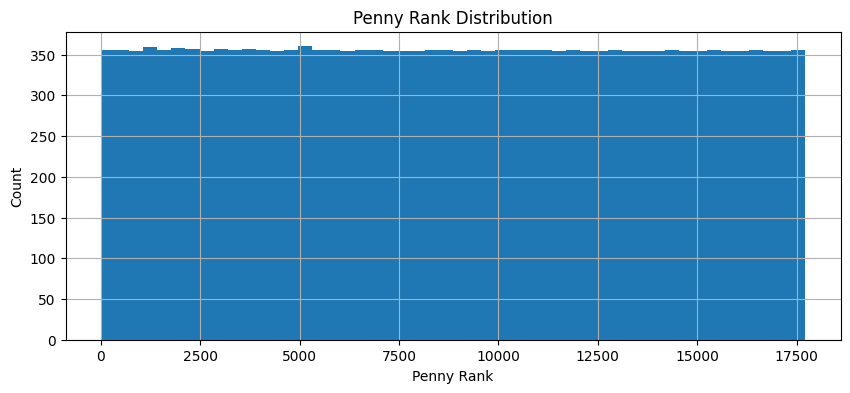

In [8]:
# Penny rank distribution
if "penny_rank" in cards_misc.columns:
    penny_non_null = cards_misc["penny_rank"].dropna()

    print(f"Non-null Penny Rank rows: {len(penny_non_null):,}")

    penny_non_null.hist(bins=50, figsize=(10, 4))
    plt.title("Penny Rank Distribution")
    plt.xlabel("Penny Rank")
    plt.ylabel("Count")
    plt.show()

In [9]:
# Life modifier inspection
if "life_modifier" in cards_misc.columns:
    display(
        cards_misc.loc[
            cards_misc["life_modifier"].notna(),
            ["name", "life_modifier"]
        ].head(20)
    )

,name,life_modifier


In [10]:
# Hand modifier inspection
if "hand_modifier" in cards_misc.columns:
    display(
        cards_misc.loc[
            cards_misc["hand_modifier"].notna(),
            ["name", "hand_modifier"]
        ].head(20)
    )

,name,hand_modifier


In [11]:
# Commander-related high EDHREC cards
if "edhrec_rank" in cards_misc.columns:
    display(
        cards_misc.sort_values("edhrec_rank").head(25)
    )

,id,oracle_id,name,edhrec_rank,penny_rank,life_modifier,hand_modifier
2027,0116a9e2-960f-45b7-84d5-ef6df51d3ef7,6ad8011d-3471-4369-9d68-b264cc027487,Sol Ring,1.0,NaN,None,None
33183,d74a72a2-d46a-41c2-a400-70571197b020,None,Sol Ring // Sol Ring,1.0,NaN,None,None
32909,bffbe9ec-edbc-43ed-a3bf-60635e7e625c,None,Command Tower // Command Tower,2.0,NaN,None,None
1530,00cd2a17-c01d-47e5-8056-db22f64921d1,0895c9b7-ae7d-4bb3-af17-3b75deb50a25,Command Tower,2.0,NaN,None,None
284,0021d6f2-cebb-4b03-b273-ecde1675af8e,0bc7f093-bef0-4f1a-852c-4b75ebf54838,Arcane Signet,3.0,NaN,None,None
3874,02351f40-b9c4-44dc-8bfb-4f146b1ae4cd,27b047e3-0d41-45e2-98e9-9391d7923a1e,Exotic Orchard,9.0,7444.0,None,None
4070,02581f6e-8606-4258-8cc0-4f0596044c50,c23e5b80-08d2-4e24-9908-fe2aa4f30f6f,Reliquary Tower,10.0,3624.0,None,None
1036,0085e973-36a4-4d2e-8e92-f2eb1d298cc2,b1544f21-7e98-461b-aed5-e748b0168c52,Swords to Plowshares,11.0,NaN,None,None
979,007e8e93-7bf4-46e6-840f-c3863579f4db,c8b143ad-43ec-4e0d-a440-e348daa31391,Swiftfoot Boots,12.0,2877.0,None,None
6196,03d2e866-ad8d-4612-9f4c-ee20f80b825c,ca204b66-8d0c-431a-8d34-282f7c2d17da,Lightning Greaves,13.0,999.0,None,None


In [12]:
# Sample rows sanity check
cards_misc.sample(10, random_state=42)

,id,oracle_id,name,edhrec_rank,penny_rank,life_modifier,hand_modifier
573,0046f098-29e8-4659-bcad-39526bf7c6aa,45f159dc-a5f9-4335-896b-ad544c303801,Geistlight Snare,15837.0,8428.0,None,None
29114,39b1bef8-8b30-49e7-a36a-5dc972df50af,8df38d95-1707-4f83-9d64-41f0be2a3b3b,Champion's Victory,28630.0,NaN,None,None
16253,0dfbdd8f-f336-4945-96d0-2c7246dec7ca,e4b1ef6a-6f05-472e-aaed-1c24dd6605c7,Far // Away,15368.0,2009.0,None,None
4097,025c83d4-ba5a-4abf-b4ac-33f68de97f7f,f066174a-a959-4365-920f-c04506d94a5a,Spirit en-Kor,20144.0,6079.0,None,None
758,0061d4da-28e0-4f95-85cc-e9377a4c8eae,ebdf26a4-77ee-4635-8d52-926bdca623f7,Lux Cannon,4345.0,6544.0,None,None
22632,1a3df725-9cb3-4fc0-a495-4fd101f45b84,156d1a58-c970-4b81-b6c7-5a0caa1699cd,Blackcleave Goblin,17481.0,12112.0,None,None
27709,2e9d1559-d4c5-4159-8728-08d7c3ea1297,9e936885-0786-41b5-933a-d0953e751116,"Vhal, Scholar of Mortality",NaN,NaN,None,None
33282,e1fb4a02-3354-44b5-87ac-813828ab251e,4426edf7-5fbb-41a2-83b9-80bf9f04651b,Swarm Saboteur,NaN,NaN,None,None
8713,05d194d8-a73d-442a-a4b4-7c46a0a81bd7,559463f8-396f-40e0-9515-a1be6397ca31,Serene Steward,18737.0,5295.0,None,None
28461,33f00b01-4d0d-40e8-b84d-6857a6d6875a,66944a11-40a1-4f3a-9f83-52324e0edfef,"Arahbo, Roar of the World",7766.0,NaN,None,None
